<a href="https://colab.research.google.com/github/JuandeDiosMG/Analysis-experiment-page-A-B/blob/main/S9_Version_Student_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
from scipy.stats import ttest_ind
from scipy.stats import levene
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**:

 El dataset no tiene valores ausentes visibles, por lo que no es necesario un trato para el manejo de los datos, un posible cambio seria el tipo de variable en la columna de fecha.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df['user_id'].describe()

count                                    40000
unique                                   40000
top       6966f2c7-1c8c-4ba0-834e-638615daff54
freq                                         1
Name: user_id, dtype: object

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df['converted'].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df['landing'].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64


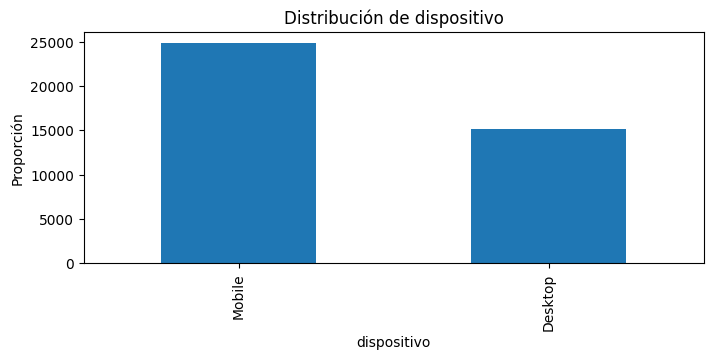

Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64


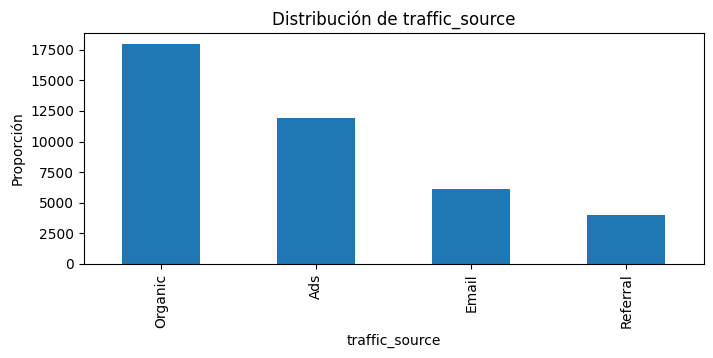

Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64


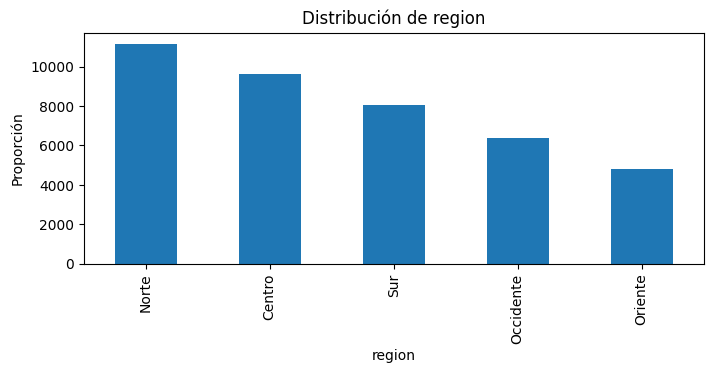

0    34294
1     5706
Name: converted, dtype: int64


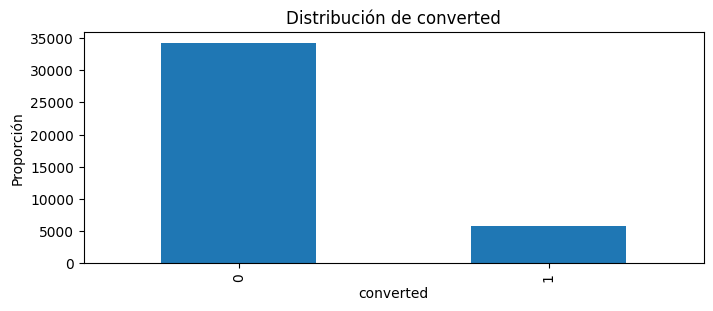

Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


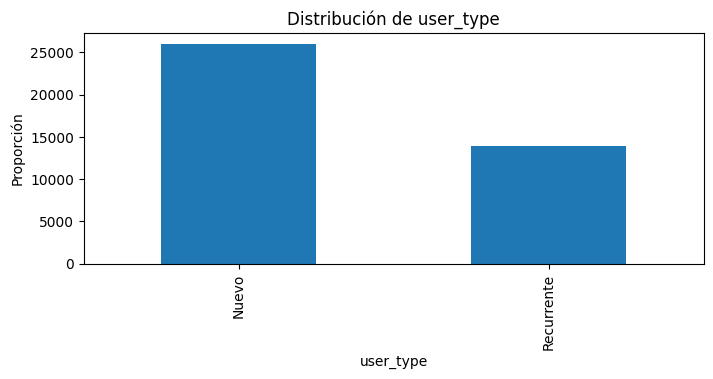

In [ ]:
for col in ["dispositivo", "traffic_source","region","converted",'user_type']:
    proporciones = df[col].value_counts()
    print(proporciones)
    plt.figure(figsize=(8, 3))
    proporciones.plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.show()

✍️ **Comentario**:

Todos lo valores son razonables, las categorías y nombres tienen sentido y los números tienen sentido en el contexto

No se encuentran datos que pudiera generar ruido.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df['converted']==1) & (df['landing']=='A')]['gasto']
gasto_B = df[(df['converted']==1) & (df['landing']=='B')]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [ ]:
print(gasto_A.describe())
print(gasto_B.describe())

count    2512.000000
mean       61.086572
std        28.875470
min        12.120000
25%        40.612500
50%        55.840000
75%        74.837500
max       303.680000
Name: gasto, dtype: float64
count    3194.00000
mean       68.74536
std        32.00102
min        12.98000
25%        45.21000
50%        62.57000
75%        84.27750
max       249.99000
Name: gasto, dtype: float64


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los clientes es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de los clientes es diferente en la página A y la página B.

In [ ]:
# Aplicar prueba

t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


In [ ]:
# Interpreta los resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de que el promedio de gastos es diferente entre la página A y B.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficientede que el promedio de gastos es diferente entre la página A y B.")

Rechazamos la hipótesis nula: hay evidencia de que el promedio de gastos es diferente entre la página A y B.


In [ ]:
# Ejecutar prueba de Levene y mostrar resultados
l_stat, p_value_var = levene(gasto_A, gasto_B)
print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p: {p_value_var}")

alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).")


Estadístico de Levene: 29.17646453202917
Valor p: 6.875301988016449e-08
Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Encunetramos pruebas estadisticamente significativas para rechazar la hipotesis nula

**Interpretación de negocio**

Con base en la prueba t, encontramos evidencia estadística de que el gasto promedio difiere entre las dos Paginas

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en ambas páginas.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre ambas páginas.

In [ ]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()


# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
conteos = [conversiones['A'],conversiones['B']]
num_observaciones = [totales['A'],totales['B']]

In [ ]:
# Obtener tasa o porcentaje de éxito por grupo
tasa_a = conteos[0]/num_observaciones[0]
tasa_b = conteos[1]/num_observaciones[1]

print(f"\nTasa A: {tasa_a:.3f}")
print(f"Tasa B: {tasa_b:.3f}")
print(f"Diferencia: {tasa_b - tasa_a:.3f}")


Tasa A: 0.126
Tasa B: 0.160
Diferencia: 0.034


In [ ]:
# Aplicar prueba

z_stat, p_value = proportions_ztest(conteos, num_observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


In [ ]:
alpha = 0.05  # umbral de significancia
if p_value >= alpha:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")
else:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Encontramos evidencia estadistica para rechazar la hipotesis nula

**Interpretación de negocio:**  
Explica qué indica el resultado sobre la tasa de conversión entre la página A y la página B.

Con base del uso de la prueba z para proporciones encontramos evidencia estadistica de unadiferencia en la tasa de conversión entre las páginas A y B

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las dos variables (son independientes)
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las dos variables (no son independientes).

In [ ]:

tabla=pd.crosstab(df['traffic_source'], df['converted'])
print(tabla)


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [ ]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")


Estadístico chi-cuadrado: 8.662
Valor P: 0.034


In [ ]:

# Intepretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")



Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Encontramos evidencia estadistica para rechazar la hipotesis nula

**Interpretación de negocio:**  
Explica qué indican los resultados considerando tanto las cantidades absolutas como las tasas de conversión.

Con base en la prueba Chi cuadrada identificamos que existe evidencia estadistica significativo para encontrar una relación entre la fuente de trafico y la conversion de compras de los usuarios.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre tipo de usuario y conversion las dos variables (son independientes)
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las variables usuario y conversion (no son independientes)

In [ ]:
tabla_2=pd.crosstab(df['user_type'], df['converted'])
print(tabla)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [ ]:
# Aplicar prueba
# Aplicar prueba
chi2_stat_2, p_value_2, dof_2, expected_2 = chi2_contingency(tabla_2)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")


Estadístico chi-cuadrado: 8.662
Valor P: 0.034


In [ ]:
# Intepretar resultados
alpha = 0.05  # umbral de significancia
if p_value_2 < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

No encontramos evidencia estadistica para rechazar la hipotesis nula

**Interpretación de negocio:**  

Con base en la prueba Chi cuadrada identificamos que no existe evidencia estadistica significativo para encontrar una relación entre el tipo de usuario y la conversion de compras de los usuarios.


## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

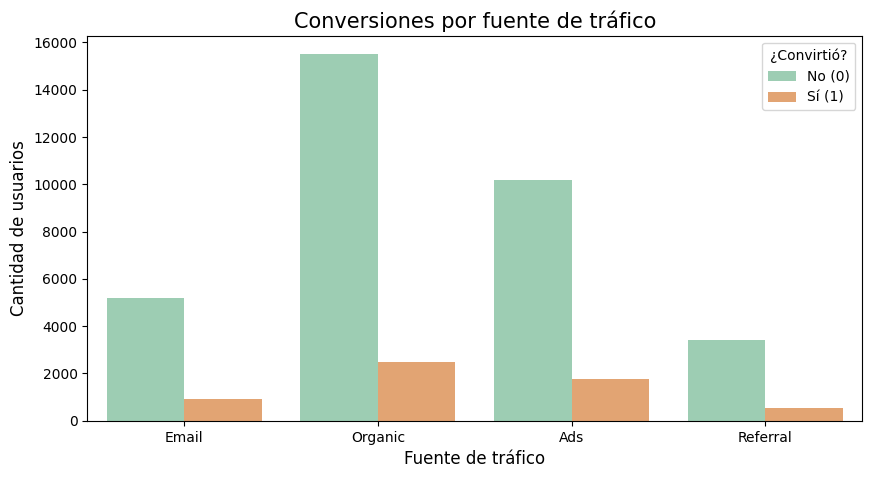

In [ ]:

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='traffic_source', hue='converted', palette = ["#95D5B2", "#F4A261"])
# Añadir detalles
plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()



✍️ **Comentario**:

Observamos que la catidad de usuarios que visitaron la página es de manera organica, seguido por aquellos que llegarón por anuncios, denotariamos que las mayores conversiones se realizaron en esa fuente de tráfico

In [ ]:
tabla_normalizada = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100

In [ ]:
tabla_normalizada

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


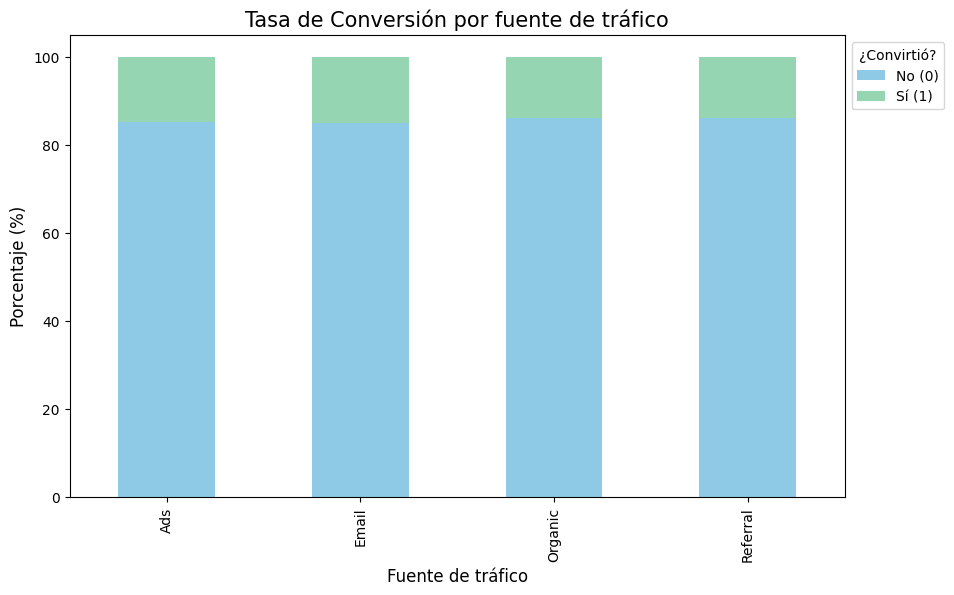

In [ ]:

# Gráfico de barras apiladas
tabla_normalizada.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por fuente de tráfico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


✍️ **Comentario**:

Se denota que del total de conversiones por fuente de tráfico la mayoria represento aproximadamente un 15%

### Relación entre el tipo de usuario y la conversión

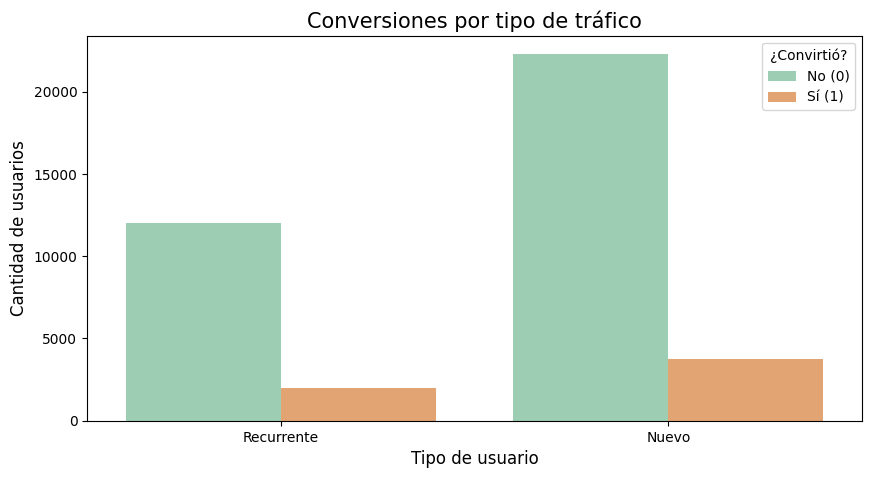

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette = ["#95D5B2", "#F4A261"])
# Añadir detalles
plt.title('Conversiones por tipo de tráfico', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()


✍️ **Comentario**:

Observamos la relacion del tipo de usuario y la cantidad de usuarios observamos que menos de 5000 usuarios son recurentes y realizaron compras, en la misma línea podemos ver que los usuarios nuevos realizaron tambien crompras por lo que no podemos encontrar un relación significativa

In [ ]:
tabla_normalizada_2 = pd.crosstab(df['user_type'], df['converted'], normalize='index')*100

In [ ]:
tabla_normalizada_2

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


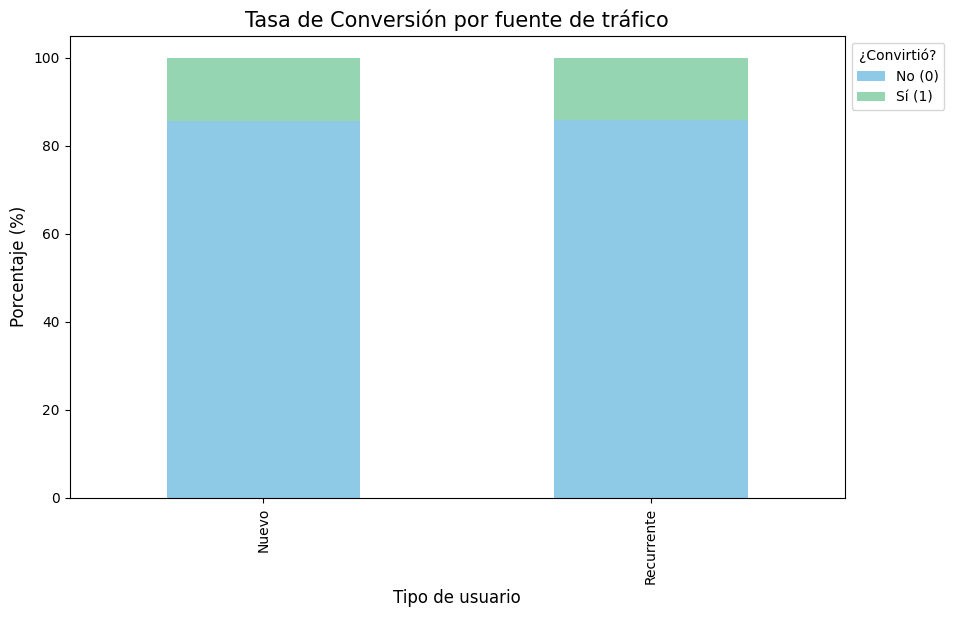

In [ ]:
# Gráfico de barras apiladas
tabla_normalizada_2.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por fuente de tráfico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


✍️ **Comentario**:

Al observar la tasa de porcentaje es similar tanto en usuarios nuevos como recurrentes por lo que nos muestra poca relacion entre la conversion de compra y el tipo de usuari

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La página B genera mayor converision y gasto promedio
- Existe una prueba estadistica que muestra una posible significacia en el uso de la página B
- **Interpretación:**
Aunque podemos oberservar mayor promedio no se puede afirmar que sea el unico factor que influya en la tasa de conversion
<br>

**Tasa de conversión:**
- El modelo de página B tiene una mayor tasa de conversion con una diferencia de un 3%
- Observamos una diferencia estadisticamente significativa por lo que estadisticamente hay una relacion entre el tipo de pagina y la conversión
- **Interpretación:**
No podemos afirmar que exista una correlacion entre el tipo de página y la conversion a compra, sin embargo podemos buscar los factores que hacieron está diferencia
---

#### 📊 **Segmentación por fuente de tráfico**
- Encontramos diferencia estadisticamente significativa entre la conversion por tipo de trafico
- **Interpretación:**
 Aunque no podemos afirmar causalidad encontramos que dependiendo de provenga el cliente aumenta la posibilida de compra.
 ---

#### 📊 **Segmentación por tipo de usuario**
- No contramos significancia estadistica para afirma que exista una direncia entre la conversion y el tipo de usuario.
- **Interpretación:**
Estadisticamente no hay una relacion entre si el tipo de usuario es nuevo o recurrente y si realiza una conversion o no.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.
- En la primera observamos una mayor cantidad de conversiones cuando la fuente es organica, sin embargo tambien existe una alsa en las corversiones por anuncios, al observar los porcentajes observamos que en el total de cada una de las fuente tiene el similar porcentaje de conversion
- En el segundo analisis observmos claramente que la diferencia entre el tipo de usuario no es grande
---

#### 💡 **Recomendaciones de negocio:**
- Se tiene que seguir revisando las causas por la mayor cantidad de gastos en la página B
- Se debe dar seguimiento las rutas de trafico que generan mayor cantidad de conversiones, dado que puede tener impacto positivo en el crecimiento del negocio.